Name:   Srujana Duggineni

ID:     C00313483

#### Meal_Type clustering using K-Means Clustering 

####  Business Understanding:

Objective: 
The principal aim of the study is to use K-Means Clustering for meal types as classified by their nutritional values concerning the Daily Food & Nutrition Dataset. This classification should enable understanding dietary habits, optimize meal planning for individual users, and offer specific nutrition recommendations.


####  Dataset Overview: 

Dataset Used: Daily Food & Nutrition Dataset
https://www.kaggle.com/datasets/adilshamim8/daily-food-and-nutrition-dataset





In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from preprocess_data import preprocess_data


#### Preparing dataset , partition data

The following EDA steps are followed (inside preprocess_data):
    1. Load dataset.
    2. Drop unwanted columns.
    3. Handle missing values.
    4. Encode categorical features.
    5. Process datetime features(NA)
    6. Remove outliers.
    7. Scale numerical features.
    8. Split into train & test sets.

In [2]:
# preprocessing dataset for classification
file_path = "/Users/dugginenisrujana/Desktop/DAA_CA /DAA_CA1/Datasets/daily_food_nutrition_dataset.csv"

### the column we want to predict
target_column = "Category" 
drop_columns = ['Date','User_ID','Food_Item','Meal_Type']

X_train, X_test, y_train, y_test = preprocess_data(file_path, target_column, drop_columns=drop_columns)

1. Load dataset.

First 5 Rows:
          Date  User_ID       Food_Item Category  Calories (kcal)  Protein (g)  \
0  2024-09-11      496            Eggs     Meat              173         42.4   
1  2024-12-17      201           Apple   Fruits               66         39.2   
2  2024-06-09      776  Chicken Breast     Meat              226         27.1   
3  2024-08-27      112          Banana   Fruits              116         43.4   
4  2024-07-28      622          Banana   Fruits              500         33.9   

   Carbohydrates (g)  Fat (g)  Fiber (g)  Sugars (g)  Sodium (mg)  \
0               83.7      1.5        1.5        12.7          752   
1               13.8      3.2        2.6        12.2          680   
2               79.1     25.8        3.2        44.7          295   
3               47.1     16.1        6.5        44.1          307   
4               75.8     47.0        7.8        19.4          358   

   Cholesterol (mg)  Meal_Type  Water_Intake (ml)  
0            

In [3]:
###Standardize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Handling class imbalance

In [4]:
# Convert pandas DataFrames/Series to numpy arrays for custom model
X_train_np = X_train.to_numpy() if isinstance(X_train, pd.DataFrame) else X_train
y_train_np = y_train.to_numpy() if isinstance(y_train, pd.Series) else y_train
# Convert target values to integers 
y_train_np = y_train_np.astype(int)
y_test = y_test.astype(int)
#### Handling class imbalance
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_np, y_train_np)


#### Hyperparameter tuning

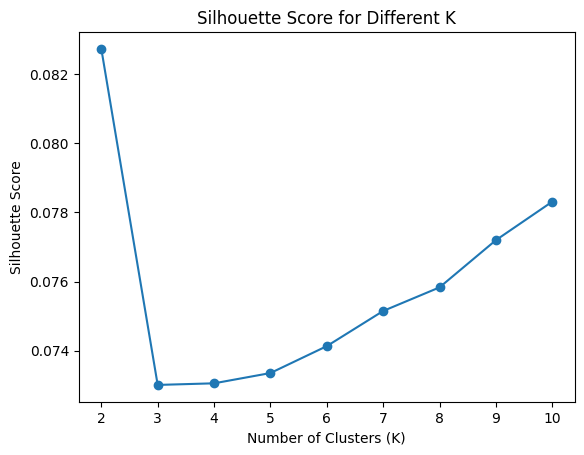

Best K (optimal clusters) according to Silhouette Score(0.08272176061074789): 2


In [5]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []
K_range = range(2, 11)  

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_np)
    score = silhouette_score(X_train_np, kmeans.labels_)
    silhouette_scores.append(score)

plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Silhouette Score for Different K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

# Find the best K
best_K = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Best K (optimal clusters) according to Silhouette Score({max(silhouette_scores)}): {best_K}")


silhouette_score:    0.08167995607041416


Text(0.5, 0, 'Feature 3')

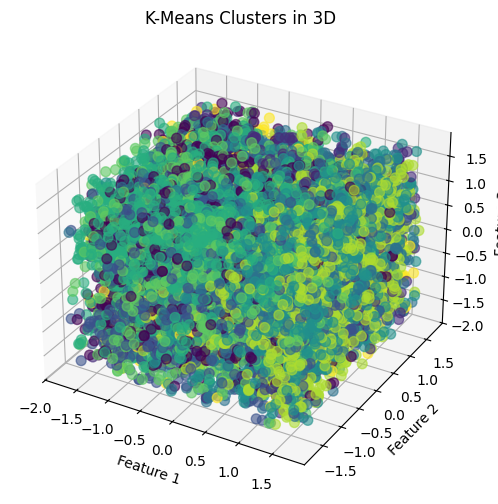

In [6]:
from mpl_toolkits.mplot3d import Axes3D
kmeans = KMeans(n_clusters=9, random_state=42)
kmeans.fit(X_train_balanced)
print(f'silhouette_score:    {silhouette_score(X_train_balanced, kmeans.labels_)}')
# Visualize the clusters

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the clusters
ax.scatter(X_train_balanced[:, 0], X_train_balanced[:, 1], X_train_balanced[:, 2], 
           c=kmeans.labels_, cmap='viridis', s=50, alpha=0.6)

# Add title and labels
ax.set_title("K-Means Clusters in 3D")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")

## using PCA to improve Silhouette Score 

Silhouette Score(after PCA ):  0.07574076954928434


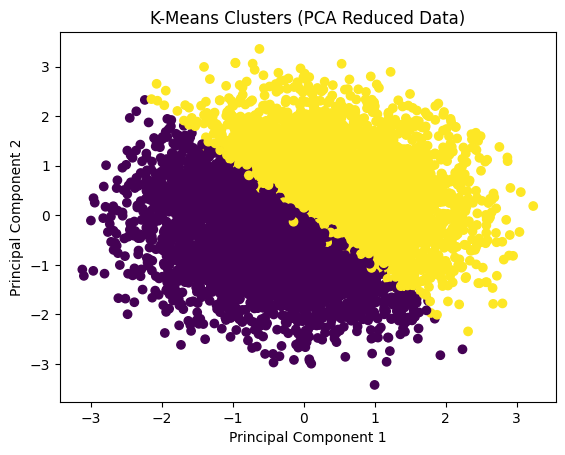

In [7]:
from sklearn.decomposition import PCA

# Reduce data to 2D using PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_train_np)

# Apply K-Means on PCA-reduced data
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_pca)
silhouette_avg = silhouette_score(X_train_np, kmeans.labels_)
print("Silhouette Score(after PCA ): ", silhouette_avg)
# Visualize the clusters
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='viridis')
plt.title("K-Means Clusters (PCA Reduced Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

### Conclusion:
- with hyperparametr tuning(k value grid search), we are able get Silhouette Score of 0.0839295427364303
- After dimensionality reduction,we are able get Silhouette Score(after PCA ):  0.04073845946537742 

so i am planning to expolore more advanced algorithm like DBSCAN to get better result

In [8]:
import joblib  # Import joblib to save the model

# Saving the Custom Model
joblib.dump(kmeans, "kmeans.pkl")


print("Models kmeans successfully!")

Models kmeans successfully!
